# Ball and Beam Simulation

Simulating a tiltiing beam balancing a ball at the middle position.

Importing packages

In [57]:
try: 
    from jax import config
    config.update("jax_enable_x64", True)
    import time
    import math
    import jax.numpy as jnp
    from meshcat import Visualizer
    import meshcat.geometry as mc_geom
    import meshcat.transformations as mc_trans
    %matplotlib ipympl
    import matplotlib.pyplot as plt
    
    # local imports
    from pid import PIDController



    print('Imported packages.')
except Exception as e:
    print('Importing packages failed:')
    print(e)



Imported packages.


Integrator and constants.

In [58]:
R = 0.01 # meter
m_ball = 0.05 # kg
m_beam = 0.5 # kg
l_beam = 0.3 # meter
I_ball = 2/5 * m_ball * R * R # kg m^2
I_beam = m_beam * l_beam * l_beam /12 # kg m^2
g = 9.81 # m/s^2
D = 100 # friction coefficient at the edges 
q_init = [0., 0., 0., jnp.pi / 36] # ball pos[m], ball angle[rad], beam pos[m], beam angle[rad]
qdot_init = [0., 0., 0., 0.] # ball v[m/s], ball omega[rad/s], beam v(always 0), beam omega[rad/s]

tf = 20
dt = 1e-2
N = int(tf/dt)
x0 = jnp.array(q_init + qdot_init)

controller = PIDController(1, 0, 0, 0)
servo_pos_controller = PIDController(5, 0, 0, 0)
servo_vel_controller = PIDController(5, 0, 0, 0)

# Runge-Kutta 4
def rk4_step(f, x0, dt):
    """
        Input:
            f(x) - function to be integrated
            x0 - current state
            dt - time step 
        Output: 
            x1 - x[n+dt] 
    """
    q, qdot = jnp.split(x0, 2)
    theta_beam_setpoint = controller.calculate(-q[0], dt)
    # servo controller(internal to the servo)
    servo_pos_controller.setpoint = theta_beam_setpoint
    omega_beam_setpoint = servo_pos_controller.calculate(q[3], dt)
    servo_vel_controller.setpoint = omega_beam_setpoint
    u = servo_vel_controller.calculate(qdot[3], dt)
    k1 = f(x0, u)
    k2 = f(x0 - + dt*k1/2, u)
    k3 = f(x0 + dt*k2/2, u)
    k4 = f(x0 + dt*k3, u)
    x1 = x0 + 1/6*(k1+2*k2+2*k3+k4)*dt
    return x1, [theta_beam_setpoint, omega_beam_setpoint, u] 

The following function computes the dynamics of the system each timestep.

In [59]:
def dyn_step(x, u):
    """
        Input: 
            state = x = [q, qdot] 
            u -> control input
        Output: 
            xdot = [qdot, qddot]
    """
    q, qdot = jnp.split(x, 2)
    # ball control(real-time simulation)
    ball_xddot = - 5 / 7 * g * math.sin(q[3])
    ball_thetaddot = ball_xddot / R
    qddot = jnp.array([ball_xddot, ball_thetaddot, 0., u])
    return jnp.hstack(jnp.array([qdot, qddot]))

Initialize the visualizer.

In [60]:
class Viewer1D(Visualizer):
    def __init__(self, R, l_beam, x_init) -> None:
        Visualizer.__init__(self)
        self._ball_R = R
        self._beam_thickness = 0.01
        self._beam = self["beam"]
        self._ball= self["end_effector"]
        self._ball.set_object(
            mc_geom.Sphere(radius=R),
            mc_geom.MeshLambertMaterial(
                    #color=0x0000ff,
                    # opacity=0.5,
                    reflectivity=0.8,
                    map=mc_geom.ImageTexture(image=mc_geom.PngImage.from_file('./BeachBallColor.jpg'))
                    )
        )
        self._beam.set_object(
            mc_geom.Box([self._beam_thickness, l_beam, self._beam_thickness]),
            mc_geom.MeshLambertMaterial(
                    color=0x00ff00,
                    # opacity=0.5,
                    reflectivity=0.8,
            )
        )
        self.render(x_init)
    def render(self, x):
            x_ball, theta_ball, _, theta_beam = x
            _T_ball = mc_trans.compose_matrix(
                            translate=[0.,x_ball * math.cos(theta_beam) + (self._ball_R + self._beam_thickness / 2) * math.cos(theta_beam + math.pi/2),x_ball * math.sin(theta_beam) + (self._ball_R + self._beam_thickness / 2) * math.sin(theta_beam + math.pi/2)], 
                            angles=[0.,theta_ball,math.pi/2]
                )
            _T_beam = mc_trans.compose_matrix(
                            translate=[0.,0,0], 
                            angles=[theta_beam, 0.,0.]
                )
            self._ball.set_transform(_T_ball)
            self._beam.set_transform(_T_beam)

viewer = Viewer1D(R, l_beam, q_init)
viewer.jupyter_cell()

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7000/static/


Live plots of the controllers' performance

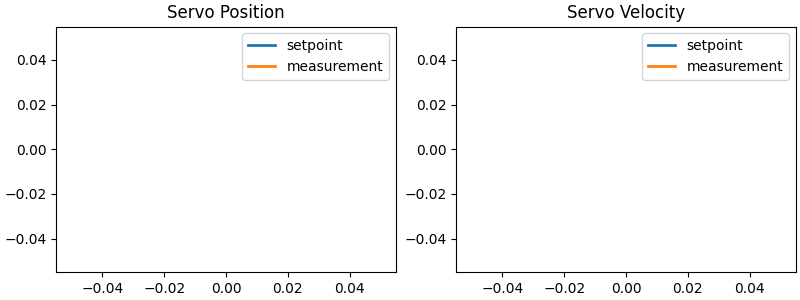

In [61]:
fig, ax = plt.subplots(
    nrows=1, ncols=2,
    figsize=(8,3),
    gridspec_kw={'width_ratios':[1,1]}
)
fig.set_constrained_layout(True)   # allow dynamic spacing

ax[0].set_title('Servo Position')
theta_beam_setpoint_x, theta_beam_setpoint_y = [], []
theta_beam_actual_x, theta_beam_actual_y = [], []
(theta_beam_setpoint_line,) = ax[0].plot([], [], lw=2, label='setpoint')
(theta_beam_actual_line,) = ax[0].plot([], [], lw=2, label='measurement')
ax[0].legend()
ax[1].set_title('Servo Velocity')
omega_beam_setpoint_x, omega_beam_setpoint_y = [], []
omega_beam_actual_x, omega_beam_actual_y = [], []
(omega_beam_setpoint_line,) = ax[1].plot([], [], lw=2, label='setpoint')
(omega_beam_actual_line,) = ax[1].plot([], [], lw=2, label='measurement')
ax[1].legend()

def update_plot(t, new_theta_beam_setpoint, new_theta_beam_actual, new_omega_beam_setpoint, new_omega_beam_actual):
    # pos
    theta_beam_setpoint_x.append(t)
    theta_beam_setpoint_y.append(new_theta_beam_setpoint)
    theta_beam_actual_x.append(t)
    theta_beam_actual_y.append(new_theta_beam_actual)
    theta_beam_setpoint_line.set_data(theta_beam_setpoint_x, theta_beam_setpoint_y)
    theta_beam_actual_line.set_data(theta_beam_actual_x, theta_beam_actual_y)
    ax[0].set_xlim(0, t)
    ax[0].set_ylim(jnp.min(jnp.array(theta_beam_actual_y + theta_beam_setpoint_y)), jnp.max(jnp.array(theta_beam_actual_y + theta_beam_setpoint_y)))
    # vel
    omega_beam_setpoint_x.append(t)
    omega_beam_setpoint_y.append(new_omega_beam_setpoint)
    omega_beam_actual_x.append(t)
    omega_beam_actual_y.append(new_omega_beam_actual)
    omega_beam_setpoint_line.set_data(omega_beam_setpoint_x, omega_beam_setpoint_y)
    omega_beam_actual_line.set_data(omega_beam_actual_x, omega_beam_actual_y)
    ax[1].set_xlim(0, t)
    ax[1].set_ylim(jnp.min(jnp.array(omega_beam_actual_y + omega_beam_setpoint_y)), jnp.max(jnp.array(omega_beam_actual_y + omega_beam_setpoint_y)))
    fig.canvas.draw()
    fig.canvas.flush_events()

## Animation

Using RK4 for integration to propagate.

In [62]:
for k in range(N):
    x0, data = rk4_step(dyn_step, x0, dt)
    q, qdot = jnp.split(x0, 2)
    update_plot(k*dt, data[0], q[3], data[1], qdot[3])
    viewer.render(q)
    time.sleep(dt)

/tmp/ipykernel_101063/1013730427.py:29: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax[0].set_xlim(0, t)
/tmp/ipykernel_101063/1013730427.py:38: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax[1].set_xlim(0, t)


KeyboardInterrupt: 